In [10]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

with open("../data/gaia_nearby_stars_enriched.json", "r") as f:
    stars = json.load(f)

df = pd.DataFrame(stars)

df.head()

df["display_name"] = df["name"].fillna(
    df["source_id"].astype(str)
)

df["distance_pc"] = (
    df["distance_light_years"] / 3.26156
)

df["absolute_magnitude"] = (
    df["phot_g_mean_mag"]
    - 5 * np.log10(df["distance_pc"])
    + 5
)

df.columns

Index(['source_id', 'ra', 'dec', 'parallax', 'distance_light_years',
       'phot_g_mean_mag', 'bp_rp', 'name', 'display_name', 'distance_pc',
       'absolute_magnitude'],
      dtype='str')

In [11]:
df.sort_values("distance_light_years").head(10)

,source_id,ra,dec,parallax,distance_light_years,phot_g_mean_mag,bp_rp,name,display_name,distance_pc,absolute_magnitude
0,5853498713190525696,217.392321,-62.676075,768.066539,4.25,8.984749,3.804580,[SBA2014] Source 1,[SBA2014] Source 1,1.303057,13.409931
1,4472832130942575872,269.448503,4.739420,546.975940,5.96,8.193974,2.833697,GES J17574778+0443542,GES J17574778+0443542,1.827346,11.884870
2,3864972938605115520,164.103190,7.002727,415.179416,7.86,11.038391,4.184836,WiggleZ S11J105623334+07003859,WiggleZ S11J105623334+07003859,2.409890,14.128405
3,762815470562110464,165.830960,35.948653,392.752945,8.30,6.551172,2.215609,NaN,762815470562110464,2.544795,9.522908
4,2947050466531873024,101.286626,-16.720933,374.489589,8.71,8.524133,-0.278427,[BG91] 3,[BG91] 3,2.670501,11.391169
5,5140693571158946048,24.771674,-17.947683,373.844312,8.72,10.817838,3.828554,G 272-61A,G 272-61A,2.673567,13.682382
6,5140693571158739840,24.771554,-17.948300,367.711896,8.87,10.507542,3.752956,G 272-61A,G 272-61A,2.719558,13.335050
7,4075141768785646848,282.458789,-23.837097,336.026602,9.71,9.126414,2.834036,CD-23 14742,CD-23 14742,2.977103,11.757445
8,1926461164913660160,355.480015,44.170376,316.481187,10.31,10.379277,3.529414,Ross 248,Ross 248,3.161064,12.880111
9,5164707970261890560,53.228293,-9.458168,310.577293,10.50,3.465752,1.140298,[CBC2016] S2,[CBC2016] S2,3.219318,5.926932


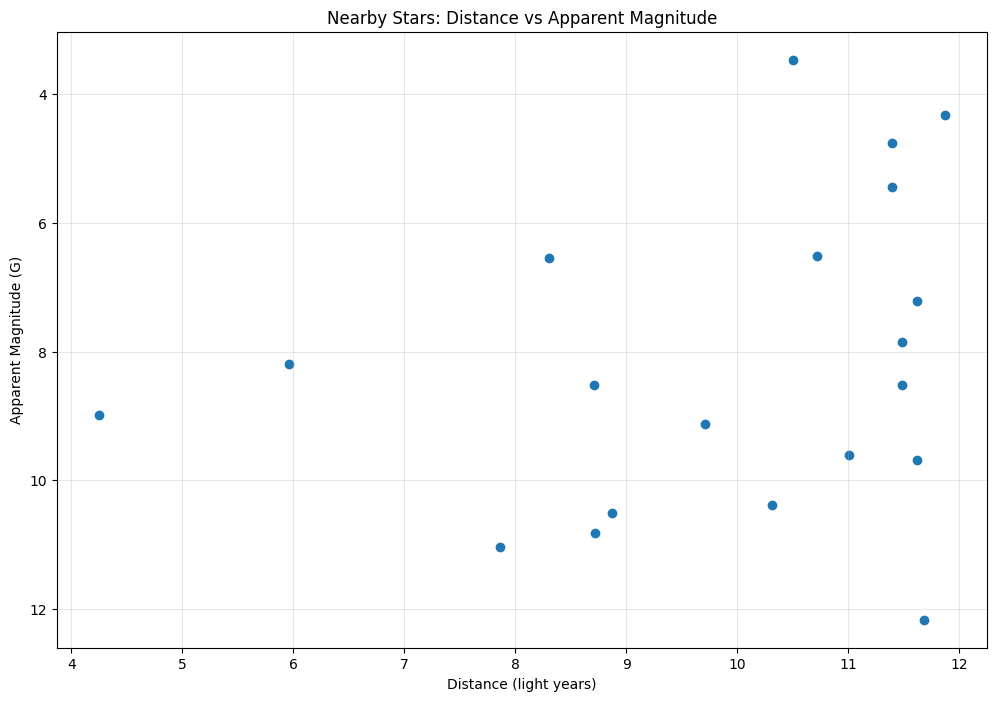

In [12]:
plt.figure(figsize=(12, 8))

plt.scatter(
    df["distance_light_years"],
    df["phot_g_mean_mag"],
)

plt.xlabel("Distance (light years)")
plt.ylabel("Apparent Magnitude (G)")
plt.title("Nearby Stars: Distance vs Apparent Magnitude")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()

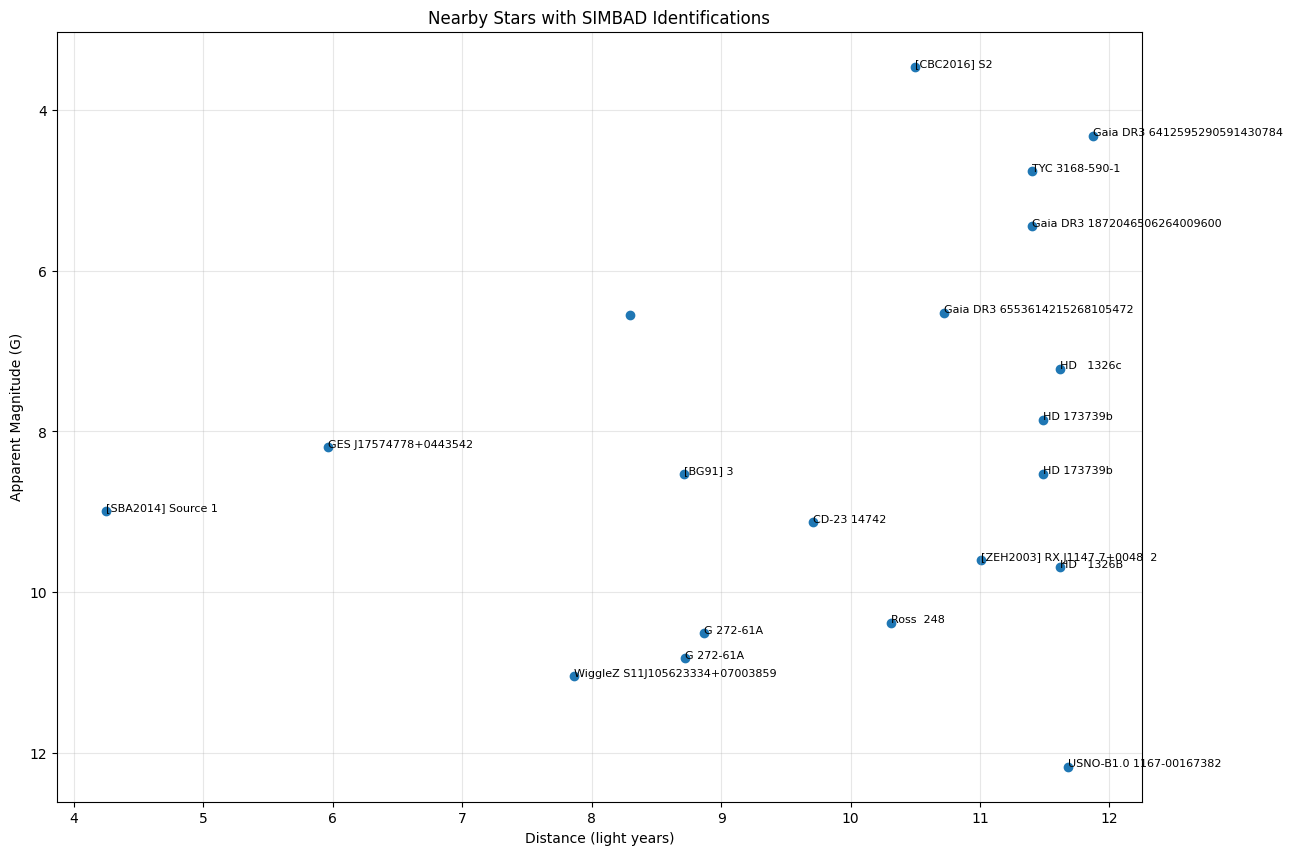

In [13]:
plt.figure(figsize=(14, 10))

plt.scatter(
    df["distance_light_years"],
    df["phot_g_mean_mag"],
)

for _, row in df.iterrows():

    if pd.notna(row["name"]):

        plt.text(
            row["distance_light_years"],
            row["phot_g_mean_mag"],
            row["display_name"],
            fontsize=8,
        )

plt.xlabel("Distance (light years)")
plt.ylabel("Apparent Magnitude (G)")
plt.title("Nearby Stars with SIMBAD Identifications")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()

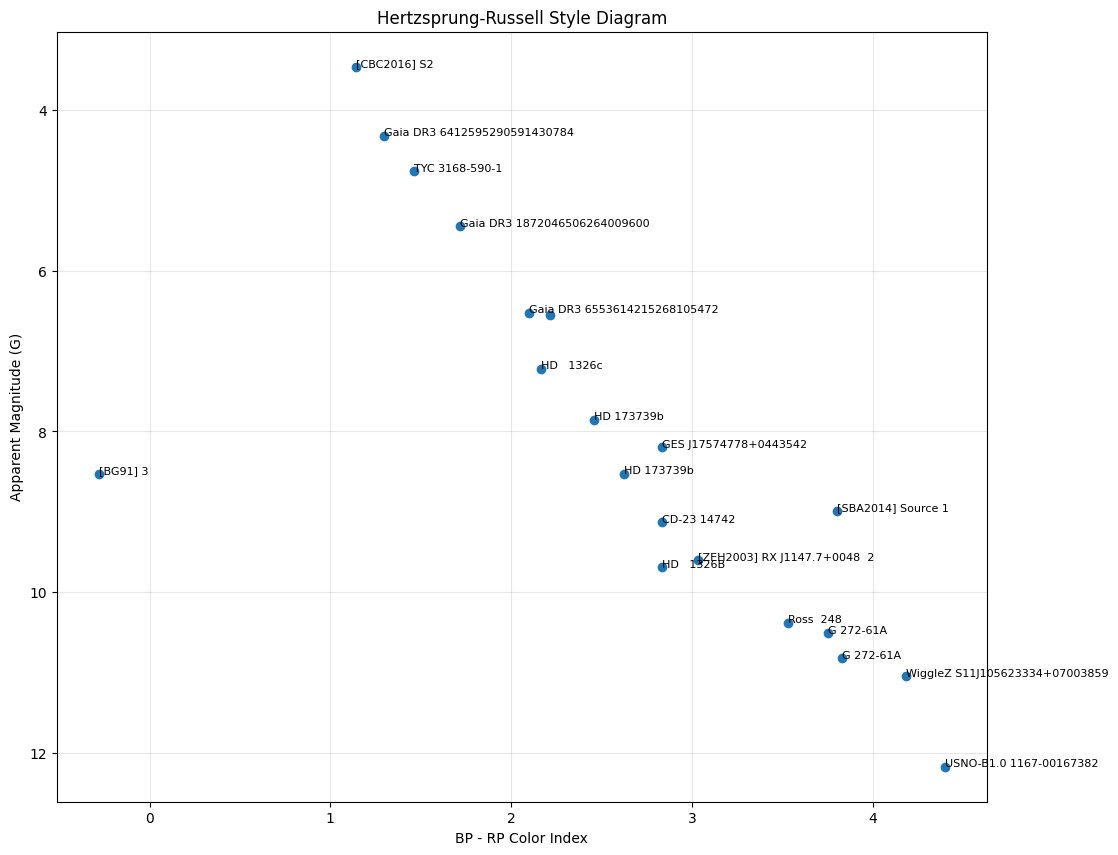

In [14]:
plt.figure(figsize=(12, 10))

plt.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
)

for _, row in df.iterrows():

    if pd.notna(row["name"]):

        plt.text(
            row["bp_rp"],
            row["phot_g_mean_mag"],
            row["display_name"],
            fontsize=8,
        )

plt.xlabel("BP - RP Color Index")
plt.ylabel("Apparent Magnitude (G)")
plt.title("Hertzsprung-Russell Style Diagram")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()

In [15]:
df[
    [
        "display_name",
        "phot_g_mean_mag",
        "distance_pc",
        "absolute_magnitude",
    ]
].head()

,display_name,phot_g_mean_mag,distance_pc,absolute_magnitude
0,[SBA2014] Source 1,8.984749,1.303057,13.409931
1,GES J17574778+0443542,8.193974,1.827346,11.884870
2,WiggleZ S11J105623334+07003859,11.038391,2.409890,14.128405
3,762815470562110464,6.551172,2.544795,9.522908
4,[BG91] 3,8.524133,2.670501,11.391169


## Real Hertzsprung–Russell Diagram

This diagram uses:

- Gaia BP-RP color index
- calculated absolute magnitude

Absolute magnitude represents the intrinsic luminosity of a star,
independent of its distance from Earth.

This is one of the most important visualizations in stellar astrophysics.

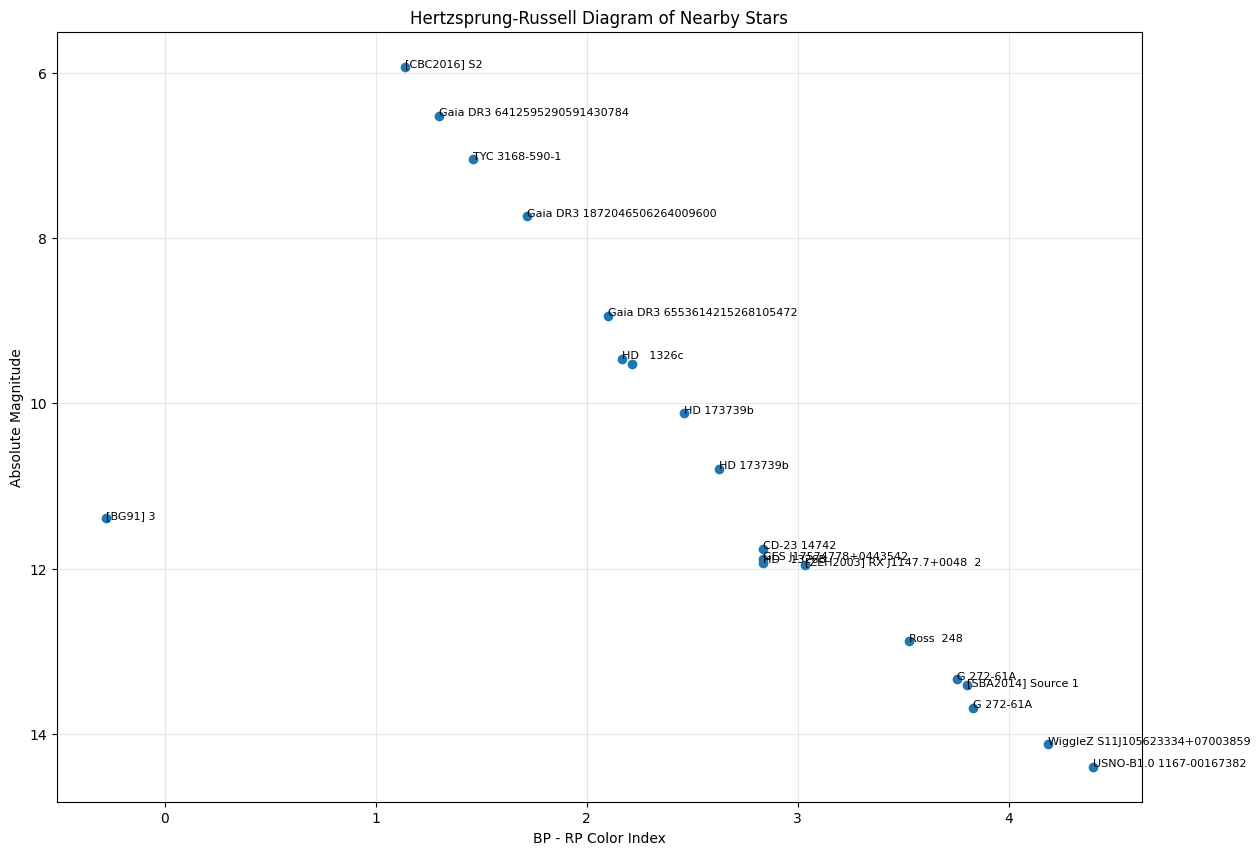

In [16]:
plt.figure(figsize=(14, 10))

plt.scatter(
    df["bp_rp"],
    df["absolute_magnitude"],
)

for _, row in df.iterrows():

    if pd.notna(row["name"]):

        plt.text(
            row["bp_rp"],
            row["absolute_magnitude"],
            row["display_name"],
            fontsize=8,
        )

plt.xlabel("BP - RP Color Index")
plt.ylabel("Absolute Magnitude")
plt.title("Hertzsprung-Russell Diagram of Nearby Stars")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()